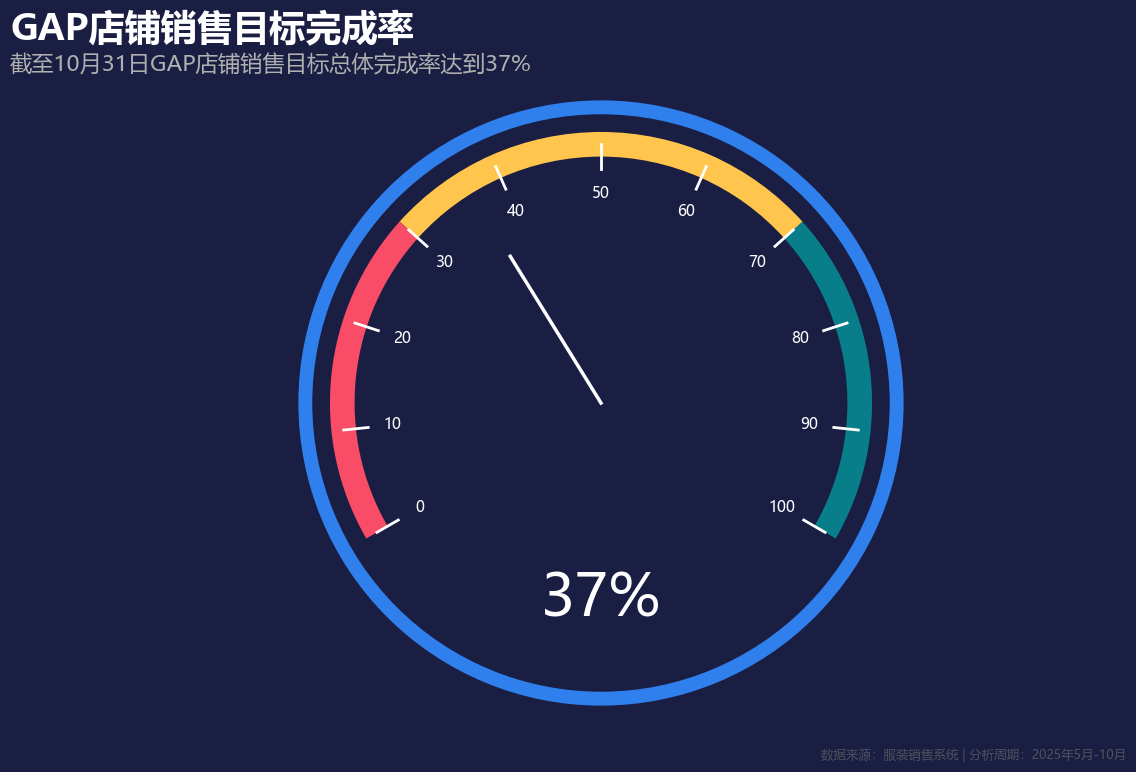

In [52]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Circle
import numpy as np
import pandas as pd

# 配色参数
bg_color   = "#1A1E43"   # 背景色
outer_blue = "#2F80ED"   # 外圈蓝色
yellow     = "#FFC54D"   # 黄色
green      = "#087E8B"   # 绿色
red        = "#F94C66"   # 红色

# 几何参数
R_outer_circle = 1.2  # 外圈蓝色圆的半径
ring_outer_r   = 1.1  # 内圈彩色环的外半径
ring_width     = 0.1  # 内圈彩色环的宽度
lw_outer       = 10.0 # 外圈蓝色圆的线宽

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']  # 支持中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

try:
    # 读取订单数据
    df_orders = pd.read_csv('../../erp_order.csv', encoding='utf-8-sig')
    
    # 检查必要列是否存在
    if '店铺名称' not in df_orders.columns or '已付金额' not in df_orders.columns or '下单时间' not in df_orders.columns:
        raise ValueError("订单数据中缺少必要列: '店铺名称'、'已付金额' 或 '下单时间'")
    
    # 过滤出包含"GAP"的店铺
    gap_orders = df_orders[df_orders['店铺名称'].str.contains('GAP', na=False)]
    
    if gap_orders.empty:
        raise ValueError("未找到包含'GAP'的店铺数据")
    
    # 计算实际销售额（已付金额总和）
    actual_sales = gap_orders['已付金额'].sum()
    
    # 设定年度销售目标 (50万人民币)
    target_sales = 500000.0
    
    # 计算完成率
    completion_rate = min(actual_sales / target_sales * 100, 100)
    
    # 获取数据覆盖的最新日期
    latest_date = pd.to_datetime(gap_orders['下单时间']).max().strftime('%m月%d日')
    
    def angle_from_value(value, min_value=0, max_value=150):
        return (value - 112.5) * (240 / (150 - 50)) + 150
    
    def add_ring_slice(ax, start_value, end_value, color, min_value=0, max_value=100):
        theta1 = angle_from_value(start_value, min_value, max_value)
        theta2 = angle_from_value(end_value, min_value, max_value)
        ax.add_patch(Wedge((0, 0), ring_outer_r, theta1, theta2, width=ring_width, facecolor=color, edgecolor='none'))
    
    # 开始绘制
    fig = plt.figure(figsize=(12, 8))
    ax = plt.gca()
    fig.patch.set_facecolor(bg_color)
    ax.set_facecolor(bg_color)
    
    # 外圈蓝色圆
    ax.add_patch(Circle((0, 0), R_outer_circle, fill=False, edgecolor=outer_blue, linewidth=lw_outer))
    
    # 内圈四色扇环
    add_ring_slice(ax, 337.5, 367.5, green)      # 绿色
    add_ring_slice(ax, 367.5, 257.5, yellow)    # 黄色
    add_ring_slice(ax, 257.5, 287.5, red)      # 红色
    
    # 加入刻度
    for value in range(0, 101, 10):
        theta = angle_from_value(value, 0, 100)
        x0 = 0.95 * np.cos(np.radians(90 - theta))
        y0 = 0.95 * np.sin(np.radians(90 - theta))
        x1 = 1.05 * np.cos(np.radians(90 - theta))
        y1 = 1.05 * np.sin(np.radians(90 - theta))
        ax.plot([x0, x1], [y0, y1], color='white', linewidth=2)
        ax.text(0.85 * np.cos(np.radians(90 - theta)), 
                0.85 * np.sin(np.radians(90 - theta)), 
                str(value), color='white', fontsize=11, ha='center', va='center')
    
    # 加入指针和中央文字
    theta = angle_from_value(completion_rate, 0, 100)
    x0, y0 = 0, 0
    x1 = 0.7 * np.cos(np.radians(90 - theta))
    y1 = 0.7 * np.sin(np.radians(90 - theta))
    ax.plot([x0, x1], [y0, y1], color='white', linewidth=2.5)
    
    # 美化
    ax.set_aspect('equal')
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)
    ax.axis('off')

    # 中心文字
    ax.text(0, -0.8, f"{completion_rate:.0f}%", fontsize=42, ha='center', va='center', color='white')
        
    # 添加标题和说明
    plt.figtext(0.02, 0.95, "GAP店铺销售目标完成率",
                ha='left', fontsize=26, color='white', fontweight='bold')
    plt.figtext(0.02, 0.91, f"截至{latest_date}GAP店铺销售目标总体完成率达到{completion_rate:.0f}%",
                ha='left', fontsize=16, color='#B0B0B0')
        
    # 添加数据来源说明
    plt.figtext(0.95, 0.05,
                '数据来源：服装销售系统 | 分析周期：2025年5月-10月',
                ha='right', fontsize=9, color='#666666', alpha=0.7)
    
    # 保存图表
    plt.savefig('GAP店铺销售目标完成率.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
    
    # 显示图表
    plt.show()

except Exception as e:
    print(f"图表生成失败: {str(e)}")
    raise